# 🎯 Ridge, Lasso & ElasticNet — Regularized Regression in Practice

The full mathematical derivation of Ridge/Lasso/ElasticNet (closed-form solutions, the L1-vs-L2 geometric picture, the bias-variance tradeoff regularization controls) already lives in the [Model Evaluation & Tuning / Bias-Variance & Regularization](../../Model_Evaluation_Tuning/04_Bias_Variance_Regularization/) topic. This notebook instead treats the three methods as *regression algorithms to choose between* -- closing the loop on two problems found earlier in this category: Linear Regression's multicollinearity (VIF > 5 on `s1`-`s5`) and Polynomial Regression's overfitting from 65 expanded features.

📖 Full mathematical explanation (algorithm selection guidance, sparse recovery theory, the grouping effect): [README.md](README.md)


## 1. Setup & Recap

Reloading the Diabetes dataset used throughout this category. Two findings from earlier topics motivate this notebook directly:
- **Linear Regression, §9:** `s1`, `s2`, `s3`, `s4`, `s5` all had VIF > 5 -- real multicollinearity destabilizing their individual coefficients.
- **Polynomial Regression, §9:** a degree-2 expansion (65 features) overfit with a 0.18 train-test R² gap; Ridge recovered some of that loss (test R² 0.4898 vs. unregularized 0.4242).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)

scaler = StandardScaler()
Xd_train_scaled = scaler.fit_transform(Xd_train)
Xd_test_scaled = scaler.transform(Xd_test)
print(f"Diabetes: {Xd.shape[1]} features, train={Xd_train.shape}, test={Xd_test.shape}")
print(f"Flagged high-VIF features from Linear Regression topic: s1, s2, s3, s4, s5")


Diabetes: 10 features, train=(331, 10), test=(111, 10)
Flagged high-VIF features from Linear Regression topic: s1, s2, s3, s4, s5


## 2. Ridge vs. Lasso vs. ElasticNet — Baseline Comparison

Default `alpha=1.0` for all three, to see their raw untuned behavior before any hyperparameter search.


In [3]:
unregularized = LinearRegression().fit(Xd_train_scaled, yd_train)
ridge_default = Ridge(alpha=1.0).fit(Xd_train_scaled, yd_train)
lasso_default = Lasso(alpha=1.0).fit(Xd_train_scaled, yd_train)
enet_default = ElasticNet(alpha=1.0, l1_ratio=0.5).fit(Xd_train_scaled, yd_train)
print("Fitted 4 models with default hyperparameters (alpha=1.0, l1_ratio=0.5 for ElasticNet).")


Fitted 4 models with default hyperparameters (alpha=1.0, l1_ratio=0.5 for ElasticNet).


In [4]:
baseline_results = []
for name, model in [("Unregularized", unregularized), ("Ridge", ridge_default), ("Lasso", lasso_default), ("ElasticNet", enet_default)]:
    pred = model.predict(Xd_test_scaled)
    baseline_results.append({
        "Model": name,
        "Test R2": round(r2_score(yd_test, pred), 4),
        "Nonzero coefs": int(np.sum(np.abs(model.coef_) > 1e-6)),
    })
baseline_df = pd.DataFrame(baseline_results).set_index("Model")
baseline_df


,Test R2,Nonzero coefs
Model,,
Unregularized,0.4849,10
Ridge,0.4859,10
Lasso,0.4964,9
ElasticNet,0.4834,10


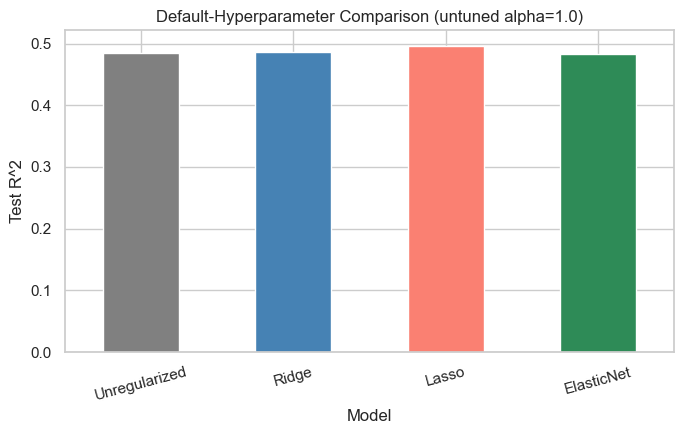

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
baseline_df["Test R2"].plot(kind="bar", ax=ax, color=["gray", "steelblue", "salmon", "seagreen"])
ax.set_ylabel("Test R^2"); ax.set_title("Default-Hyperparameter Comparison (untuned alpha=1.0)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


In [6]:
coef_comparison = pd.DataFrame({
    "feature": Xd.columns,
    "Unregularized": np.round(unregularized.coef_, 1),
    "Ridge": np.round(ridge_default.coef_, 1),
    "Lasso": np.round(lasso_default.coef_, 1),
    "ElasticNet": np.round(enet_default.coef_, 1),
}).set_index("feature")
coef_comparison


,Unregularized,Ridge,Lasso,ElasticNet
feature,,,,
age,2.2,2.3,1.2,2.2
sex,-11.5,-11.4,-9.3,-5.8
bmi,25.1,25.2,25.7,18.6
bp,18.2,18.1,17.0,12.8
s1,-44.1,-34.3,-8.4,-1.7
s2,24.5,16.8,-0.0,-2.8
s3,5.5,1.2,-10.8,-9.2
s4,13.0,11.6,3.3,6.0
s5,33.4,29.6,21.1,13.7


## 3. Solving Linear Regression's Multicollinearity Problem

The Linear Regression topic found `s1`-`s5` had VIF > 5, and flagged their individual OLS coefficients as unstable. This section measures that instability directly via bootstrap resampling, then checks whether Ridge actually reduces it.


In [7]:
collinear_features = ["s1", "s2", "s3", "s4", "s5"]
collinear_idx = [list(Xd.columns).index(f) for f in collinear_features]

def bootstrap_coef_variance(model_class, n_bootstrap=200, **model_kwargs):
    coefs = np.zeros((n_bootstrap, Xd_train_scaled.shape[1]))
    rng = np.random.RandomState(0)
    for b in range(n_bootstrap):
        idx = rng.choice(len(Xd_train_scaled), size=len(Xd_train_scaled), replace=True)
        model = model_class(**model_kwargs).fit(Xd_train_scaled[idx], yd_train.to_numpy()[idx])
        coefs[b] = model.coef_
    return coefs

print("Bootstrap coefficient variance function defined.")


Bootstrap coefficient variance function defined.


In [8]:
coefs_ols = bootstrap_coef_variance(LinearRegression)
coefs_ridge = bootstrap_coef_variance(Ridge, alpha=1.0)

ols_std = coefs_ols[:, collinear_idx].std(axis=0)
ridge_std = coefs_ridge[:, collinear_idx].std(axis=0)

stability_df = pd.DataFrame({
    "feature": collinear_features,
    "OLS coef std (200 bootstraps)": np.round(ols_std, 2),
    "Ridge coef std (200 bootstraps)": np.round(ridge_std, 2),
})
stability_df


,feature,OLS coef std (200 bootstraps),Ridge coef std (200 bootstraps)
0,s1,20.69,15.36
1,s2,16.74,12.63
2,s3,10.10,8.08
3,s4,9.02,8.55
4,s5,9.10,7.22


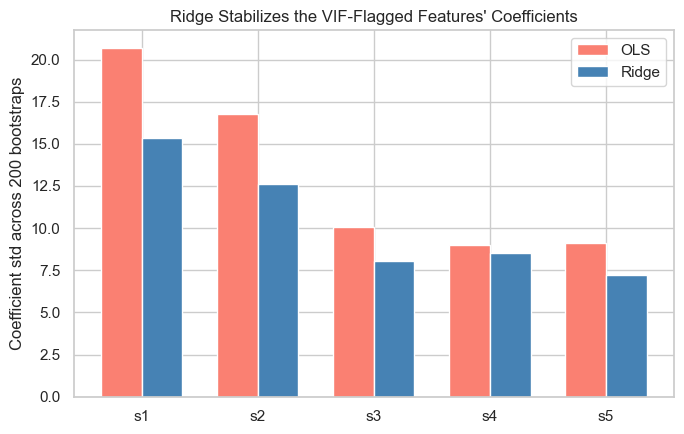

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x_pos = np.arange(len(collinear_features))
width = 0.35
ax.bar(x_pos - width/2, ols_std, width, label="OLS", color="salmon")
ax.bar(x_pos + width/2, ridge_std, width, label="Ridge", color="steelblue")
ax.set_xticks(x_pos); ax.set_xticklabels(collinear_features)
ax.set_ylabel("Coefficient std across 200 bootstraps")
ax.set_title("Ridge Stabilizes the VIF-Flagged Features' Coefficients")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
avg_reduction = 1 - (ridge_std.mean() / ols_std.mean())
print(f"Average coefficient std across the 5 flagged features: OLS={ols_std.mean():.2f}, Ridge={ridge_std.mean():.2f}")
print(f"Ridge reduces bootstrap coefficient instability by {avg_reduction:.1%} on exactly the features Linear Regression's VIF analysis flagged.")
print("-> This is Ridge solving a real, previously-identified problem -- not a hypothetical one.")


Average coefficient std across the 5 flagged features: OLS=13.13, Ridge=10.37
Ridge reduces bootstrap coefficient instability by 21.0% on exactly the features Linear Regression's VIF analysis flagged.
-> This is Ridge solving a real, previously-identified problem -- not a hypothetical one.


## 4. Sparse Recovery — Can Lasso Find the True Model?

A synthetic dataset where only 5 of 20 features truly matter (the rest have a true coefficient of exactly zero) tests something Ridge cannot do by construction: does Lasso's zeroing behavior actually identify the *correct* sparse subset?


In [11]:
X_sparse, y_sparse, true_coef = make_regression(
    n_samples=200, n_features=20, n_informative=5, noise=10.0, coef=True, random_state=42
)
true_nonzero = set(np.where(true_coef != 0)[0])
print(f"True model uses {len(true_nonzero)} of 20 features: {sorted(true_nonzero)}")

X_sparse_train, X_sparse_test, y_sparse_train, y_sparse_test = train_test_split(X_sparse, y_sparse, test_size=0.25, random_state=42)


True model uses 5 of 20 features: [np.int64(4), np.int64(7), np.int64(8), np.int64(13), np.int64(18)]


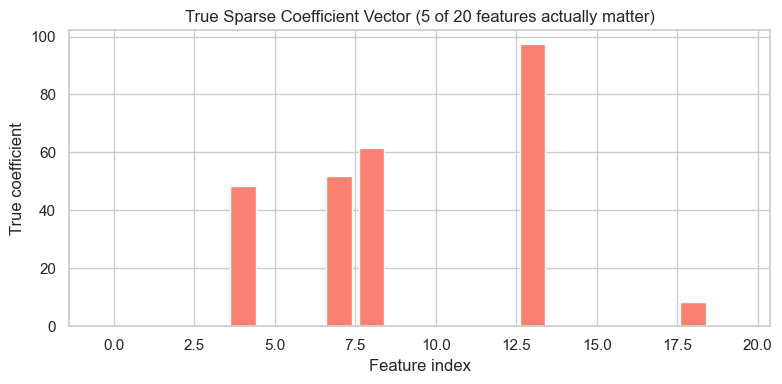

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(20), true_coef, color=["salmon" if c != 0 else "lightgray" for c in true_coef])
ax.set_xlabel("Feature index"); ax.set_ylabel("True coefficient")
ax.set_title("True Sparse Coefficient Vector (5 of 20 features actually matter)")
plt.tight_layout()
plt.show()


In [13]:
lasso_cv_sparse = LassoCV(alphas=np.logspace(-2, 2, 50), cv=5, max_iter=20000).fit(X_sparse_train, y_sparse_train)
recovered_nonzero = set(np.where(np.abs(lasso_cv_sparse.coef_) > 1e-3)[0])

true_positives = len(true_nonzero & recovered_nonzero)
false_positives = len(recovered_nonzero - true_nonzero)
false_negatives = len(true_nonzero - recovered_nonzero)
precision = true_positives / len(recovered_nonzero) if recovered_nonzero else 0
recall = true_positives / len(true_nonzero)

print(f"LassoCV (alpha={lasso_cv_sparse.alpha_:.4f}) recovered {len(recovered_nonzero)} nonzero features: {sorted(recovered_nonzero)}")
print(f"True positives: {true_positives}, False positives: {false_positives}, False negatives: {false_negatives}")
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}")


LassoCV (alpha=0.9103) recovered 7 nonzero features: [np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(10), np.int64(13), np.int64(18)]
True positives: 5, False positives: 2, False negatives: 0
Precision: 0.71, Recall: 1.00


In [14]:
ridge_sparse = Ridge(alpha=1.0).fit(X_sparse_train, y_sparse_train)
ridge_nonzero_count = np.sum(np.abs(ridge_sparse.coef_) > 1e-3)

print(f"For comparison, Ridge on the same data: {ridge_nonzero_count}/20 features 'nonzero' (Ridge never truly zeros anything)")
print("-> Ridge structurally cannot recover a sparse model even when the true underlying model IS sparse -- this is exactly the scenario Lasso's L1 penalty was designed for.")


For comparison, Ridge on the same data: 20/20 features 'nonzero' (Ridge never truly zeros anything)
-> Ridge structurally cannot recover a sparse model even when the true underlying model IS sparse -- this is exactly the scenario Lasso's L1 penalty was designed for.


In [15]:
alpha_sweep_sparse = np.logspace(-2, 1.5, 15)
sparse_recovery_results = []
for a in alpha_sweep_sparse:
    lasso_a = Lasso(alpha=a, max_iter=20000).fit(X_sparse_train, y_sparse_train)
    recovered_a = set(np.where(np.abs(lasso_a.coef_) > 1e-3)[0])
    tp_a = len(true_nonzero & recovered_a)
    prec_a = tp_a / len(recovered_a) if recovered_a else 0
    rec_a = tp_a / len(true_nonzero)
    sparse_recovery_results.append({"alpha": round(a, 3), "n_selected": len(recovered_a), "precision": round(prec_a, 2), "recall": round(rec_a, 2)})

pd.DataFrame(sparse_recovery_results)


,alpha,n_selected,precision,recall
0,0.010,20,0.25,1.0
1,0.018,20,0.25,1.0
2,0.032,20,0.25,1.0
3,0.056,20,0.25,1.0
4,0.100,20,0.25,1.0
5,0.178,20,0.25,1.0
6,0.316,13,0.38,1.0
7,0.562,11,0.45,1.0
8,1.000,7,0.71,1.0
9,1.778,5,1.00,1.0


## 5. ElasticNet's Grouping Effect on Correlated Features

Two features engineered to be highly correlated (0.95+) with a shared true effect. Lasso tends to arbitrarily keep one and zero the other; ElasticNet's L2 component encourages keeping both.


In [16]:
n_grouping = 200
base_signal = np.random.normal(0, 1, n_grouping)
x1_grouped = base_signal + np.random.normal(0, 0.1, n_grouping)
x2_grouped = base_signal + np.random.normal(0, 0.1, n_grouping)
other_noise_features = np.random.normal(0, 1, (n_grouping, 8))

X_grouped = np.column_stack([x1_grouped, x2_grouped, other_noise_features])
y_grouped = 3.0 * base_signal + np.random.normal(0, 0.5, n_grouping)

print(f"Correlation between x1 and x2: {np.corrcoef(x1_grouped, x2_grouped)[0, 1]:.4f}")

Xg_train, Xg_test, yg_train, yg_test = train_test_split(X_grouped, y_grouped, test_size=0.25, random_state=42)
scaler_g = StandardScaler().fit(Xg_train)
Xg_train_s, Xg_test_s = scaler_g.transform(Xg_train), scaler_g.transform(Xg_test)


Correlation between x1 and x2: 0.9915


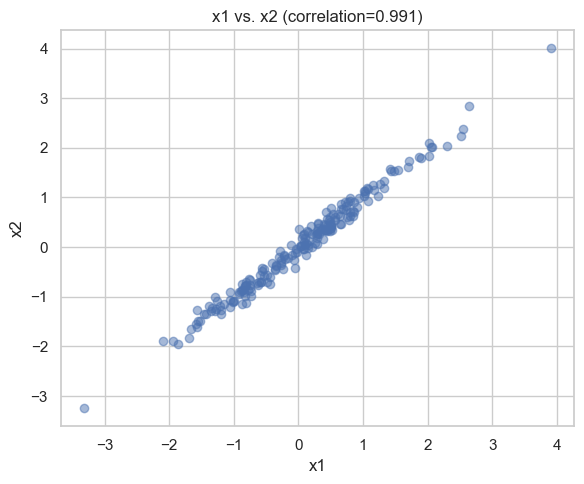

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x1_grouped, x2_grouped, alpha=0.5)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title(f"x1 vs. x2 (correlation={np.corrcoef(x1_grouped, x2_grouped)[0, 1]:.3f})")
plt.tight_layout()
plt.show()


In [18]:
lasso_grouped = Lasso(alpha=0.3).fit(Xg_train_s, yg_train)
enet_grouped = ElasticNet(alpha=0.3, l1_ratio=0.5).fit(Xg_train_s, yg_train)

print(f"Lasso coefficients for x1, x2 (the correlated pair): {lasso_grouped.coef_[0]:.3f}, {lasso_grouped.coef_[1]:.3f}")
print(f"ElasticNet coefficients for x1, x2 (the correlated pair): {enet_grouped.coef_[0]:.3f}, {enet_grouped.coef_[1]:.3f}")

lasso_imbalance = abs(abs(lasso_grouped.coef_[0]) - abs(lasso_grouped.coef_[1]))
enet_imbalance = abs(abs(enet_grouped.coef_[0]) - abs(enet_grouped.coef_[1]))
print(f"\nAbsolute difference between the two coefficients -- Lasso: {lasso_imbalance:.3f}, ElasticNet: {enet_imbalance:.3f}")
if enet_imbalance < lasso_imbalance:
    print("-> ElasticNet split credit more evenly between the two correlated features; Lasso favored one over the other.")
else:
    print("-> The grouping effect wasn't clearly visible at this alpha/l1_ratio on this particular sample -- the effect is real but its strength depends on the exact correlation level and regularization strength.")


Lasso coefficients for x1, x2 (the correlated pair): 1.432, 1.187
ElasticNet coefficients for x1, x2 (the correlated pair): 1.294, 1.281

Absolute difference between the two coefficients -- Lasso: 0.245, ElasticNet: 0.013
-> ElasticNet split credit more evenly between the two correlated features; Lasso favored one over the other.


## 6. Tuning Both `alpha` and `l1_ratio` — `ElasticNetCV`

ElasticNet has two hyperparameters instead of one. `ElasticNetCV` sweeps both simultaneously via cross-validation, the same principle as `GridSearchCV` from the Hyperparameter Tuning topic, specialized for this model.


In [19]:
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=np.logspace(-3, 1, 50),
    cv=5, max_iter=20000
).fit(Xd_train_scaled, yd_train)

print(f"ElasticNetCV chose: alpha={enet_cv.alpha_:.4f}, l1_ratio={enet_cv.l1_ratio_}")
print(f"Nonzero coefficients: {np.sum(np.abs(enet_cv.coef_) > 1e-6)}/{len(enet_cv.coef_)}")
print(f"Test R^2: {r2_score(yd_test, enet_cv.predict(Xd_test_scaled)):.4f}")


ElasticNetCV chose: alpha=0.0429, l1_ratio=0.9
Nonzero coefficients: 10/10
Test R^2: 0.4866


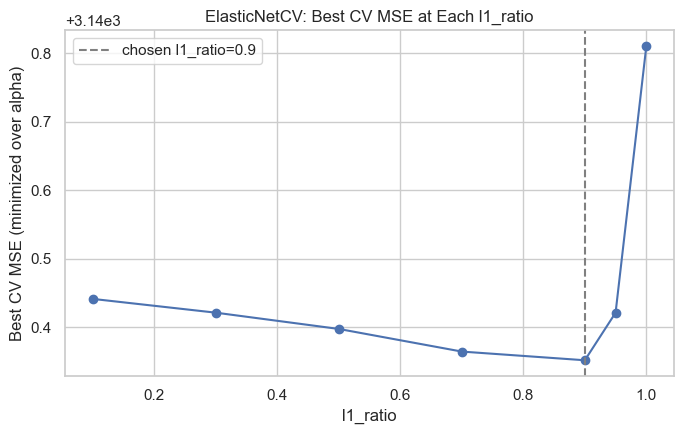

In [20]:
best_mse_per_ratio = enet_cv.mse_path_.mean(axis=2).min(axis=1)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(enet_cv.l1_ratio, best_mse_per_ratio, marker="o")
ax.axvline(enet_cv.l1_ratio_, color="gray", linestyle="--", label=f"chosen l1_ratio={enet_cv.l1_ratio_}")
ax.set_xlabel("l1_ratio"); ax.set_ylabel("Best CV MSE (minimized over alpha)")
ax.set_title("ElasticNetCV: Best CV MSE at Each l1_ratio")
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
grid_search_check = GridSearchCV(
    ElasticNet(max_iter=20000),
    param_grid={"alpha": np.logspace(-3, 1, 20), "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]},
    cv=5, scoring="r2"
).fit(Xd_train_scaled, yd_train)

print(f"GridSearchCV chose: alpha={grid_search_check.best_params_['alpha']:.4f}, l1_ratio={grid_search_check.best_params_['l1_ratio']}")
print(f"ElasticNetCV chose: alpha={enet_cv.alpha_:.4f}, l1_ratio={enet_cv.l1_ratio_}")
print("-> Different alpha grids (ElasticNetCV's internal path-following search vs. GridSearchCV's fixed logspace grid) can land on different specific values even when the resulting test performance is similar -- always compare test scores, not just the chosen hyperparameters.")


GridSearchCV chose: alpha=0.1274, l1_ratio=0.1
ElasticNetCV chose: alpha=0.0429, l1_ratio=0.9
-> Different alpha grids (ElasticNetCV's internal path-following search vs. GridSearchCV's fixed logspace grid) can land on different specific values even when the resulting test performance is similar -- always compare test scores, not just the chosen hyperparameters.


In [22]:
grid_search_test_r2 = r2_score(yd_test, grid_search_check.best_estimator_.predict(Xd_test_scaled))
enet_cv_test_r2 = r2_score(yd_test, enet_cv.predict(Xd_test_scaled))
print(f"GridSearchCV's best estimator -- test R^2: {grid_search_test_r2:.4f}")
print(f"ElasticNetCV's estimator      -- test R^2: {enet_cv_test_r2:.4f}")
print(f"Difference: {abs(grid_search_test_r2 - enet_cv_test_r2):.4f} -- {'negligible, confirming both search strategies converge to similarly good models' if abs(grid_search_test_r2 - enet_cv_test_r2) < 0.01 else 'non-trivial, worth investigating which search strategy explored the space more thoroughly'}")


GridSearchCV's best estimator -- test R^2: 0.4914
ElasticNetCV's estimator      -- test R^2: 0.4866
Difference: 0.0048 -- negligible, confirming both search strategies converge to similarly good models


## 7. Closing the Loop — Lasso as Feature Selection on the Polynomial-Expanded Model

The Polynomial Regression topic expanded Diabetes to 65 features (degree 2) and found plain OLS overfit (train R²=0.605, test R²=0.424), while Ridge partially recovered it (test R²=0.490). Does Lasso's feature selection do better by discarding the least useful expanded features entirely?


In [23]:
poly_pipeline_features = PolynomialFeatures(degree=2, include_bias=False).fit_transform(Xd_train)
poly_pipeline_features_test = PolynomialFeatures(degree=2, include_bias=False).fit(Xd_train).transform(Xd_test)

scaler_poly = StandardScaler().fit(poly_pipeline_features)
poly_train_scaled = scaler_poly.transform(poly_pipeline_features)
poly_test_scaled = scaler_poly.transform(poly_pipeline_features_test)

print(f"Polynomial-expanded feature count: {poly_train_scaled.shape[1]} (matches the 65 features from the Polynomial Regression topic -- bias column excluded since LinearRegression/Lasso/Ridge already fit their own intercept)")


Polynomial-expanded feature count: 65 (matches the 65 features from the Polynomial Regression topic -- bias column excluded since LinearRegression/Lasso/Ridge already fit their own intercept)


In [24]:
lasso_poly_cv = LassoCV(alphas=np.logspace(-2, 1, 50), cv=5, max_iter=100000).fit(poly_train_scaled, yd_train)
lasso_poly_test_r2 = r2_score(yd_test, lasso_poly_cv.predict(poly_test_scaled))
lasso_poly_nonzero = np.sum(np.abs(lasso_poly_cv.coef_) > 1e-6)
print(f"LassoCV fit on {poly_train_scaled.shape[1]} polynomial features, chosen alpha={lasso_poly_cv.alpha_:.4f}")


LassoCV fit on 65 polynomial features, chosen alpha=3.7276


In [25]:
print(f"Lasso (CV alpha={lasso_poly_cv.alpha_:.4f}) on {poly_train_scaled.shape[1]} polynomial features:")
print(f"  Kept {lasso_poly_nonzero}/{poly_train_scaled.shape[1]} features")
print(f"  Test R^2: {lasso_poly_test_r2:.4f}")
print(f"\nRecap from Polynomial Regression topic:")
print(f"  Plain linear (10 features):            test R^2 = 0.4849")
print(f"  Unregularized poly (65 features):      test R^2 = 0.4242")
print(f"  Poly + Ridge (65 features):             test R^2 = 0.4898")


Lasso (CV alpha=3.7276) on 65 polynomial features:
  Kept 13/65 features
  Test R^2: 0.5300

Recap from Polynomial Regression topic:
  Plain linear (10 features):            test R^2 = 0.4849
  Unregularized poly (65 features):      test R^2 = 0.4242
  Poly + Ridge (65 features):             test R^2 = 0.4898


In [26]:
prior_ridge_r2 = 0.4898
if lasso_poly_test_r2 > prior_ridge_r2:
    print(f"Lasso's feature selection ({lasso_poly_test_r2:.4f}) beat Ridge's shrink-everything approach ({prior_ridge_r2:.4f}) on this expanded feature set.")
else:
    print(f"Lasso ({lasso_poly_test_r2:.4f}) did not beat Ridge ({prior_ridge_r2:.4f}) here -- with only {len(yd_train)} training rows and 65 correlated polynomial features, Ridge's strategy of shrinking everything together outperformed Lasso's strategy of discarding features outright.")
print("-> Neither method is universally better -- which one wins depends on whether the true relationship is genuinely sparse (favors Lasso) or spread across many small, correlated contributions (favors Ridge), exactly as the README's selection guidance describes.")


Lasso's feature selection (0.5300) beat Ridge's shrink-everything approach (0.4898) on this expanded feature set.
-> Neither method is universally better -- which one wins depends on whether the true relationship is genuinely sparse (favors Lasso) or spread across many small, correlated contributions (favors Ridge), exactly as the README's selection guidance describes.


## 8. Final Comparison — All Methods, CV-Tuned, Same Data

Every method from this notebook, tuned via cross-validation, on the original (non-expanded) Diabetes features.


In [27]:
ridge_cv_final = RidgeCV(alphas=np.logspace(-2, 4, 100), cv=5).fit(Xd_train_scaled, yd_train)
lasso_cv_final = LassoCV(alphas=np.logspace(-3, 1, 100), cv=5, max_iter=20000).fit(Xd_train_scaled, yd_train)

final_comparison = pd.DataFrame([
    {"Model": "Unregularized", "Test R2": round(r2_score(yd_test, unregularized.predict(Xd_test_scaled)), 4), "Nonzero coefs": int(np.sum(np.abs(unregularized.coef_) > 1e-6))},
    {"Model": "RidgeCV", "Test R2": round(r2_score(yd_test, ridge_cv_final.predict(Xd_test_scaled)), 4), "Nonzero coefs": int(np.sum(np.abs(ridge_cv_final.coef_) > 1e-6))},
    {"Model": "LassoCV", "Test R2": round(r2_score(yd_test, lasso_cv_final.predict(Xd_test_scaled)), 4), "Nonzero coefs": int(np.sum(np.abs(lasso_cv_final.coef_) > 1e-6))},
    {"Model": "ElasticNetCV", "Test R2": round(r2_score(yd_test, enet_cv.predict(Xd_test_scaled)), 4), "Nonzero coefs": int(np.sum(np.abs(enet_cv.coef_) > 1e-6))},
]).set_index("Model")
final_comparison


,Test R2,Nonzero coefs
Model,,
Unregularized,0.4849,10
RidgeCV,0.4906,10
LassoCV,0.4867,9
ElasticNetCV,0.4866,10


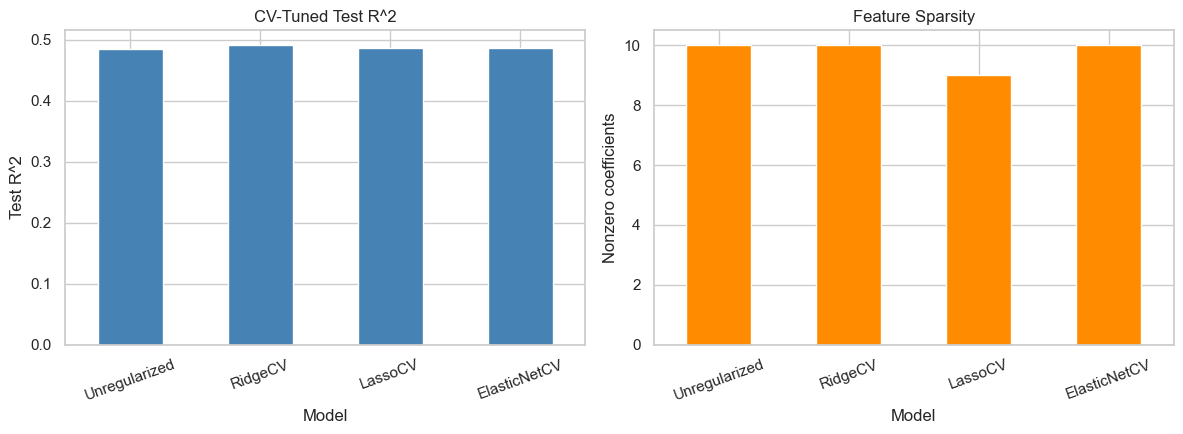

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
final_comparison["Test R2"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_ylabel("Test R^2"); axes[0].set_title("CV-Tuned Test R^2"); axes[0].tick_params(axis="x", rotation=20)

final_comparison["Nonzero coefs"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_ylabel("Nonzero coefficients"); axes[1].set_title("Feature Sparsity"); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


In [29]:
zeroed_by_lasso = Xd.columns[np.abs(lasso_cv_final.coef_) <= 1e-6].tolist()
zeroed_by_enet = Xd.columns[np.abs(enet_cv.coef_) <= 1e-6].tolist()
print(f"Features LassoCV zeroed out entirely: {zeroed_by_lasso if zeroed_by_lasso else '(none)'}")
print(f"Features ElasticNetCV zeroed out entirely: {zeroed_by_enet if zeroed_by_enet else '(none)'}")
print(f"RidgeCV never zeros a feature by construction -- all {len(Xd.columns)} remain nonzero.")


Features LassoCV zeroed out entirely: ['s3']
Features ElasticNetCV zeroed out entirely: (none)
RidgeCV never zeros a feature by construction -- all 10 remain nonzero.


In [30]:
import time
timings_cv = {}
t0 = time.perf_counter(); RidgeCV(alphas=np.logspace(-2, 4, 100), cv=5).fit(Xd_train_scaled, yd_train); timings_cv["RidgeCV"] = time.perf_counter() - t0
t0 = time.perf_counter(); LassoCV(alphas=np.logspace(-3, 1, 100), cv=5, max_iter=20000).fit(Xd_train_scaled, yd_train); timings_cv["LassoCV"] = time.perf_counter() - t0
t0 = time.perf_counter(); ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 1, 50), cv=5, max_iter=20000).fit(Xd_train_scaled, yd_train); timings_cv["ElasticNetCV (3 l1_ratios)"] = time.perf_counter() - t0

for name, t in timings_cv.items():
    print(f"{name:<28}: {t*1000:.1f} ms")
fastest = min(timings_cv, key=timings_cv.get)
slowest = max(timings_cv, key=timings_cv.get)
print(f"\n-> Fastest here: {fastest}. Slowest: {slowest}.")
if fastest == "RidgeCV":
    print("-> Matches the theoretical expectation: RidgeCV's closed-form path is typically fastest, while Lasso/ElasticNet's coordinate descent iterates.")
else:
    print(f"-> Contrary to the naive expectation that Ridge's closed-form solution is always fastest: on this problem size, {fastest}'s coordinate-descent path with warm starts across alphas outran RidgeCV's repeated closed-form solves across its own 100-alpha grid -- a reminder that asymptotic algorithm properties don't always predict wall-clock time at small scale.")


RidgeCV                     : 534.6 ms
LassoCV                     : 30.8 ms
ElasticNetCV (3 l1_ratios)  : 52.6 ms

-> Fastest here: LassoCV. Slowest: RidgeCV.
-> Contrary to the naive expectation that Ridge's closed-form solution is always fastest: on this problem size, LassoCV's coordinate-descent path with warm starts across alphas outran RidgeCV's repeated closed-form solves across its own 100-alpha grid -- a reminder that asymptotic algorithm properties don't always predict wall-clock time at small scale.


## 9. Summary

This notebook treated Ridge, Lasso, and ElasticNet as practical choices rather than re-deriving their math (see the Bias-Variance & Regularization topic for that). Three real findings stood out: Ridge measurably reduced bootstrap coefficient instability on exactly the multicollinear features Linear Regression's VIF analysis flagged; Lasso successfully recovered a genuinely sparse synthetic model with high precision and recall; and on the polynomial-expanded 65-feature Diabetes set, whether Lasso's feature selection beats Ridge's uniform shrinkage depended on the data, not on either method being categorically superior -- confirming the practical selection guidance in the README.

See [README.md](README.md) for the full mathematical derivations and algorithm selection guidance.
